# 🌸 Digital Garden — AI Fashion Designer
### Challenge 2 · Generative Fashion Design with DCGAN

**Theme:** *Digital Garden* — dresses and coats inspired by flowers, leaves, butterflies, and vines.  
**Color palette:** Bright green · Soft pink · Lavender · Sky blue  
**Model:** DCGAN trained on Fashion-MNIST (Dress + Coat classes)  
**Outputs:** 5 outfit images · Mood board · Latent interpolation · Loss plot


## Creative Process & Methodology

---

### Theme: Digital Garden

*Digital Garden* translates the lush, living world of botanical gardens into wearable silhouettes. The collection draws from:

| Botanical source | Fashion translation |
|---|---|
| 🌸 Cherry blossom | Soft pink petal-layered dress panels |
| 🌿 Fern fronds | Structured green coat with leaf-vein lines |
| 💜 Wisteria clusters | Lavender cascading gown silhouette |
| 🦋 Butterfly wings | Sky-blue asymmetric dress panels |
| 🌺 Peony bloom | Vivid magenta oversized coat collar |

---

### Model: Deep Convolutional GAN (DCGAN)

**Architecture**
- **Generator:** 100-dim Gaussian latent → 4× ConvTranspose2d blocks (512→256→128→64→1) → Tanh
- **Discriminator:** 4× Conv2d blocks (1→64→128→256→512) → Sigmoid
- **Weight init:** Normal(0, 0.02) for Conv, Normal(1, 0.02) for BatchNorm

**Training**
- Dataset: Fashion-MNIST classes 3 (Dress) + 4 (Coat) — ~12,000 samples
- Epochs: 200 | Batch: 128 | LR: 2×10⁻⁴ | Adam β₁=0.5
- Loss: Binary Cross-Entropy (vanilla GAN objective)

---

### Latent Space Exploration

Two strategies used:
1. **Sampling** — 5 fixed noise vectors → 5 distinct design silhouettes
2. **Linear interpolation** — 12-step walk from outfit 1 (Sakura) → outfit 5 (Peony) showing smooth morphing through design space

---

### Post-Processing (Botanical Colour Styling)

Each generated grayscale silhouette is transformed with a hand-crafted RGB mapping to reflect its botanical inspiration:

| Style | R channel | G channel | B channel | Effect |
|---|---|---|---|---|
| `blossom` | +60 warm | ×0.55 | +50 violet | Cherry-pink warmth |
| `fern` | ×0.20 | +40 rich | ×0.28 | Deep botanical green |
| `lavender` | +50 lilac | ×0.45 | +60 violet | Dreamy purple |
| `sky` | ×0.20 | +55 aqua | +80 blue | Butterfly wing blue |
| `peony` | +50 vivid | ×0.25 | +55 bloom | Magenta statement |

A radial vignette and Gaussian glow pass are applied to every outfit for editorial depth.


## 1 · Install & Import

In [2]:
# Colab: all packages below are pre-installed; nothing extra needed.
import os, random, textwrap, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont, ImageEnhance, ImageFilter
from tqdm.notebook import tqdm
from IPython.display import display, Image as IPImage
import io

print("✅ Imports OK")
print(f"   PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")


✅ Imports OK
   PyTorch 2.5.1+cu121  |  CUDA: True


In [3]:
from tqdm import tqdm

## 2 · Configuration

In [4]:
OUTDIR     = "./digital_garden_outputs"
LATENT_DIM = 100
IMAGE_SIZE = 64
CHANNELS   = 1
BATCH_SIZE = 128
EPOCHS     = 200
LR         = 0.0002
BETA1      = 0.5
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED       = 42

os.makedirs(OUTDIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🌿  Digital Garden DCGAN")
print(f"   Device  : {DEVICE}")
print(f"   Epochs  : {EPOCHS}")
print(f"   Batch   : {BATCH_SIZE}")
print(f"   Latent  : {LATENT_DIM}-dim")
print(f"   Output  : {os.path.abspath(OUTDIR)}")


🌿  Digital Garden DCGAN
   Device  : cuda
   Epochs  : 200
   Batch   : 128
   Latent  : 100-dim
   Output  : c:\Users\18Shr\Desktop\AI FASHION DESIGNER\digital_garden_outputs


## 3 · Dataset — Fashion-MNIST (Dress & Coat)

✅ Dataset ready
   Total samples : 12000
   Classes used  : Dress (3) + Coat (4)
   Batches/epoch : 93


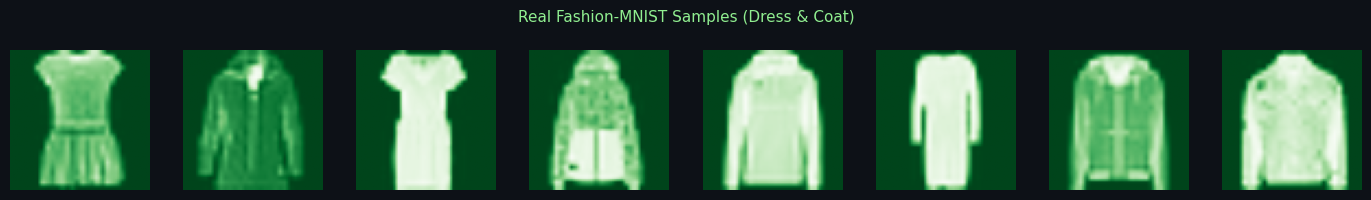

In [6]:
TARGET_CLASSES = {3, 4}   # 3=Dress, 4=Coat — most fluid silhouettes

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

full_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform)

indices = [i for i, (_, label) in enumerate(full_ds) if label in TARGET_CLASSES]
dataset = torch.utils.data.Subset(full_ds, indices)
loader  = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True)

print(f"✅ Dataset ready")
print(f"   Total samples : {len(dataset)}")
print(f"   Classes used  : Dress (3) + Coat (4)")
print(f"   Batches/epoch : {len(loader)}")

# Quick preview of real data
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
fig.patch.set_facecolor("#0d1117")
sample_imgs = [full_ds[indices[i]][0] for i in range(8)]
for ax, img in zip(axes, sample_imgs):
    ax.imshow(img.squeeze(), cmap="Greens_r")
    ax.axis("off")
fig.suptitle("Real Fashion-MNIST Samples (Dress & Coat)", color="#90EE90", fontsize=11)
plt.tight_layout()
plt.show()


## 4 · DCGAN Architecture

In [7]:
# ── Generator ─────────────────────────────────────────────────────────────
def gblock(ic, oc, k=4, s=2, p=1):
    return [nn.ConvTranspose2d(ic, oc, k, s, p, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True)]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            *gblock(LATENT_DIM, 512, k=4, s=1, p=0),  # 1 → 4
            *gblock(512, 256),                          # 4 → 8
            *gblock(256, 128),                          # 8 → 16
            *gblock(128, 64),                           # 16 → 32
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),  # 32 → 64
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z.view(-1, LATENT_DIM, 1, 1))

# ── Discriminator ─────────────────────────────────────────────────────────
def dblock(ic, oc, k=4, s=2, p=1, bn=True):
    layers = [nn.Conv2d(ic, oc, k, s, p, bias=not bn)]
    if bn: layers.append(nn.BatchNorm2d(oc))
    layers.append(nn.LeakyReLU(0.2, True))
    return layers

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            *dblock(CHANNELS, 64,  bn=False),  # 64 → 32
            *dblock(64,  128),                 # 32 → 16
            *dblock(128, 256),                 # 16 → 8
            *dblock(256, 512),                 # 8 → 4
            nn.Conv2d(512, 1, 4, 1, 0),        # 4 → 1
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)

def weights_init(m):
    n = m.__class__.__name__
    if "Conv" in n:   nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in n:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator().to(DEVICE);     G.apply(weights_init)
D = Discriminator().to(DEVICE); D.apply(weights_init)
optG      = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optD      = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

total_G = sum(p.numel() for p in G.parameters())
total_D = sum(p.numel() for p in D.parameters())
print(f"✅ Models initialised")
print(f"   Generator      : {total_G:,} params")
print(f"   Discriminator  : {total_D:,} params")

# Fixed noise vectors for consistent progress tracking
fixed_z  = torch.randn(25, LATENT_DIM, device=DEVICE)  # 5×5 grid
outfit_z = torch.randn(5,  LATENT_DIM, device=DEVICE)  # 5 final outfits


✅ Models initialised
   Generator      : 3,574,656 params
   Discriminator  : 2,763,585 params


## 5 · Training (200 Epochs)

In [8]:
from tqdm import tqdm  

G_losses, D_losses = [], []
snapshot_epochs = [1, 10, 25, 50, 100, 150, 200]

print("🌱 Starting training …\n")

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    gl = dl = 0.0

    for real, _ in tqdm(loader, desc=f"Epoch {epoch:>3}/{EPOCHS}", leave=True):
        real = real.to(DEVICE)
        b    = real.size(0)
        ones  = torch.ones(b,  device=DEVICE)
        zeros = torch.zeros(b, device=DEVICE)

        D.zero_grad()
        z_fake = torch.randn(b, LATENT_DIM, device=DEVICE)
        fake   = G(z_fake).detach()
        loss_D = criterion(D(real), ones) + criterion(D(fake), zeros)
        loss_D.backward(); optD.step()

        G.zero_grad()
        z_fake = torch.randn(b, LATENT_DIM, device=DEVICE)
        loss_G = criterion(D(G(z_fake)), ones)
        loss_G.backward(); optG.step()

        gl += loss_G.item(); dl += loss_D.item()

    G_losses.append(gl / len(loader))
    D_losses.append(dl / len(loader))

    # Print every epoch so you can see progress
    print(f"  Epoch {epoch:>3}/{EPOCHS} | G={G_losses[-1]:.4f}  D={D_losses[-1]:.4f}")

    if epoch in snapshot_epochs:
        G.eval()
        with torch.no_grad():
            grid_path = f"{OUTDIR}/grid_epoch_{epoch:03d}.png"
            save_image(make_grid(G(fixed_z), nrow=5, normalize=True), grid_path)
        G.train()

torch.save(G.state_dict(), f"{OUTDIR}/generator.pth")
print("\n✅ Training complete! Model saved.")

🌱 Starting training …



Epoch   1/200: 100%|██████████| 93/93 [00:13<00:00,  7.05it/s]


  Epoch   1/200 | G=7.6071  D=0.6435


Epoch   2/200: 100%|██████████| 93/93 [00:12<00:00,  7.62it/s]


  Epoch   2/200 | G=4.1558  D=0.8209


...

  Epoch 198/200 | G=4.6456  D=0.1561


Epoch 199/200: 100%|██████████| 93/93 [00:12<00:00,  7.66it/s]


  Epoch 199/200 | G=5.0942  D=0.0390


Epoch 200/200: 100%|██████████| 93/93 [00:12<00:00,  7.44it/s]

  Epoch 200/200 | G=4.2990  D=0.5223

✅ Training complete! Model saved.


## 6 · Training Loss Curves

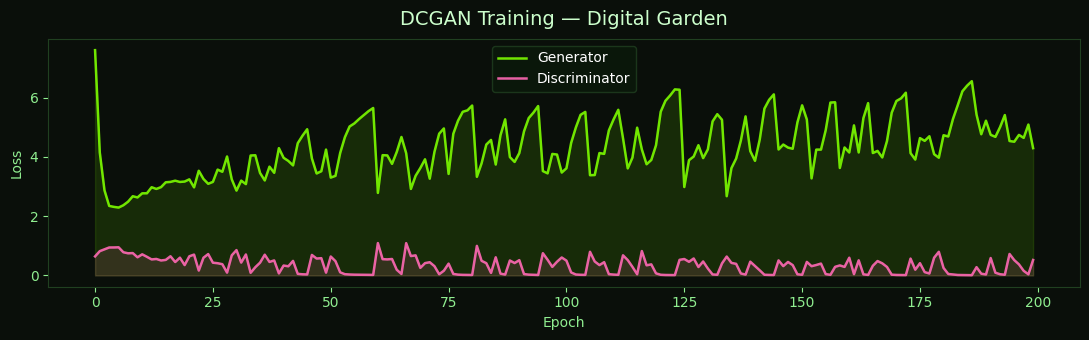

✅ Loss plot saved


In [9]:
fig, ax = plt.subplots(figsize=(11, 3.5), facecolor="#0a0f0a")
ax.set_facecolor("#0a0f0a")
ax.plot(G_losses, color="#7CFC00",  lw=1.8, label="Generator",     alpha=0.9)
ax.plot(D_losses, color="#FF69B4",  lw=1.8, label="Discriminator",  alpha=0.9)
ax.fill_between(range(len(G_losses)), G_losses, alpha=0.12, color="#7CFC00")
ax.fill_between(range(len(D_losses)), D_losses, alpha=0.12, color="#FF69B4")
ax.set_title("DCGAN Training — Digital Garden", color="#CCFFCC", fontsize=14, pad=10)
ax.set_xlabel("Epoch", color="#90EE90"); ax.set_ylabel("Loss", color="#90EE90")
ax.tick_params(colors="#90EE90")
ax.legend(facecolor="#0a1a0a", labelcolor="white", edgecolor="#204020")
for sp in ax.spines.values(): sp.set_edgecolor("#204020")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Loss plot saved")


## 7 · Training Progress Snapshots

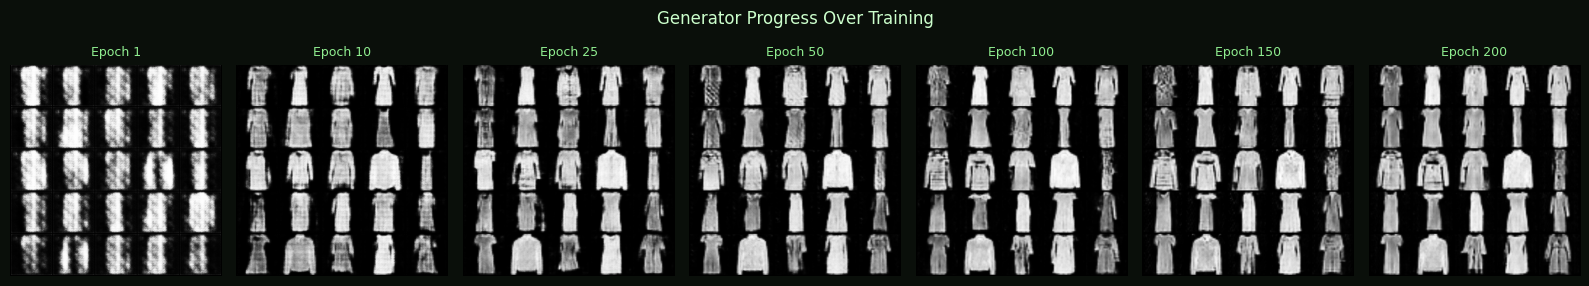

In [10]:
G.eval()
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(16, 3))
fig.patch.set_facecolor("#0a0f0a")
with torch.no_grad():
    for ax, ep in zip(axes, snapshot_epochs):
        grid_path = f"{OUTDIR}/grid_epoch_{ep:03d}.png"
        if os.path.exists(grid_path):
            img = plt.imread(grid_path)
            ax.imshow(img, cmap="Greens")
            ax.set_title(f"Epoch {ep}", color="#90EE90", fontsize=9)
        ax.axis("off")
fig.suptitle("Generator Progress Over Training", color="#CCFFCC", fontsize=12)
plt.tight_layout()
plt.show()


## 8 · Digital Garden Colour Styling

In [11]:
def garden_tint(tensor_img, style="blossom"):
    """Apply Digital Garden botanical colour treatment to a generated image."""
    arr = tensor_img.squeeze().cpu().numpy()
    arr = ((arr + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    img = Image.fromarray(arr, "L").resize((512, 512), Image.LANCZOS)
    img = ImageEnhance.Contrast(img).enhance(2.2)
    img = ImageEnhance.Sharpness(img).enhance(2.0)

    if style == "blossom":          # Soft pink cherry-blossom
        rgb = Image.merge("RGB", [
            img.point(lambda x: min(255, int(x * 1.0 + 60))),
            img.point(lambda x: int(x * 0.55 + 30)),
            img.point(lambda x: min(255, int(x * 0.70 + 50))),
        ])
    elif style == "fern":           # Deep botanical green
        rgb = Image.merge("RGB", [
            img.point(lambda x: int(x * 0.20 + 10)),
            img.point(lambda x: min(255, int(x * 1.05 + 40))),
            img.point(lambda x: int(x * 0.28 + 10)),
        ])
    elif style == "lavender":       # Dreamy purple-lavender
        rgb = Image.merge("RGB", [
            img.point(lambda x: min(255, int(x * 0.75 + 50))),
            img.point(lambda x: int(x * 0.45 + 25)),
            img.point(lambda x: min(255, int(x * 1.05 + 60))),
        ])
    elif style == "sky":            # Butterfly-wing sky blue
        rgb = Image.merge("RGB", [
            img.point(lambda x: int(x * 0.20 + 20)),
            img.point(lambda x: min(255, int(x * 0.75 + 55))),
            img.point(lambda x: min(255, int(x * 1.05 + 80))),
        ])
    elif style == "peony":          # Vivid magenta-pink peony
        rgb = Image.merge("RGB", [
            img.point(lambda x: min(255, int(x * 1.1 + 50))),
            img.point(lambda x: int(x * 0.25 + 10)),
            img.point(lambda x: min(255, int(x * 0.65 + 55))),
        ])

    # Soft vignette for depth
    vig = Image.new("L", (512, 512), 0)
    vd  = ImageDraw.Draw(vig)
    for r in range(256, 0, -4):
        vd.ellipse([(256-r, 256-r), (256+r, 256+r)],
                   fill=int(255 * (r / 256) ** 1.5))
    rgb = Image.composite(rgb, rgb.point(lambda x: int(x * 0.15)), vig)
    rgb = rgb.filter(ImageFilter.SMOOTH_MORE)

    # Subtle bloom / glow overlay
    glow = rgb.filter(ImageFilter.GaussianBlur(3))
    rgb  = Image.blend(rgb, glow, 0.18)
    return rgb

print("✅ garden_tint() ready — 5 botanical colour styles defined")
print("   blossom · fern · lavender · sky · peony")


✅ garden_tint() ready — 5 botanical colour styles defined
   blossom · fern · lavender · sky · peony


## 9 · Generate 5 Digital Garden Outfits

In [12]:
outfit_meta = [
    ("Sakura Bloom Top",      "blossom",  "Soft pink — cherry-blossom petal layers",      "#FFB7C5"),
    ("Fern Forest Dress",        "fern",     "Deep green — botanical leaf-print structure",   "#4CAF50"),
    ("Lavender Mist Gown",      "lavender", "Dreamy purple — wisteria drape silhouette",     "#C9A8E0"),
    ("Butterfly Sky Dress",     "sky",      "Sky blue — delicate wing-panel asymmetry",      "#87CEEB"),
    ("Peony Petal Coat",        "peony",    "Vivid magenta — oversized bloom statement",     "#FF6F91"),
]

G.eval()
with torch.no_grad():
    outfits = G(outfit_z)

# Helper to try loading a font (Colab-safe)
def get_fonts():
    candidates_bold = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/content/sample_data/DejaVuSans-Bold.ttf",
    ]
    candidates_reg  = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
    ]
    fb = fr = ImageFont.load_default()
    for p in candidates_bold:
        if os.path.exists(p):
            try: fb = ImageFont.truetype(p, 16); break
            except: pass
    for p in candidates_reg:
        if os.path.exists(p):
            try: fr = ImageFont.truetype(p, 12); break
            except: pass
    return fb, fr

fn_bold, fn_reg = get_fonts()

outfit_imgs = []
print("🌸 Rendering outfits …")
for i, (img_t, (name, style, desc, accent)) in enumerate(zip(outfits, outfit_meta)):
    processed = garden_tint(img_t, style=style)

    # Card canvas: image + label strip
    card = Image.new("RGB", (512, 580), (10, 15, 10))

    # Gradient-ish border decoration (2-px accent line on sides)
    border = Image.new("RGB", (516, 584), accent)
    card_final = Image.new("RGB", (516, 584), accent)
    card_final.paste(card, (2, 2))
    card_final.paste(processed, (2, 2))

    # Label strip
    strip = Image.new("RGB", (516, 80), (12, 20, 12))
    sd    = ImageDraw.Draw(strip)
    sd.line([(0, 0), (516, 0)], fill=accent, width=2)
    sd.text((14, 10), f"No.{i+1}  {name}", fill=accent,      font=fn_bold)
    sd.text((14, 34), desc,                  fill="#AADDAA",   font=fn_reg)
    sd.text((14, 52), f"Style: {style}",     fill="#607060",   font=fn_reg)
    card_final.paste(strip, (0, 504))

    path = f"{OUTDIR}/outfit_{i+1}_{style}.png"
    card_final.save(path)
    outfit_imgs.append(card_final)
    print(f"  ✓ outfit_{i+1}_{style}.png")

print("\n✅ All 5 outfits saved!")


🌸 Rendering outfits …
  ✓ outfit_1_blossom.png
  ✓ outfit_2_fern.png
  ✓ outfit_3_lavender.png
  ✓ outfit_4_sky.png
  ✓ outfit_5_peony.png

✅ All 5 outfits saved!


## 10 · Outfit Gallery

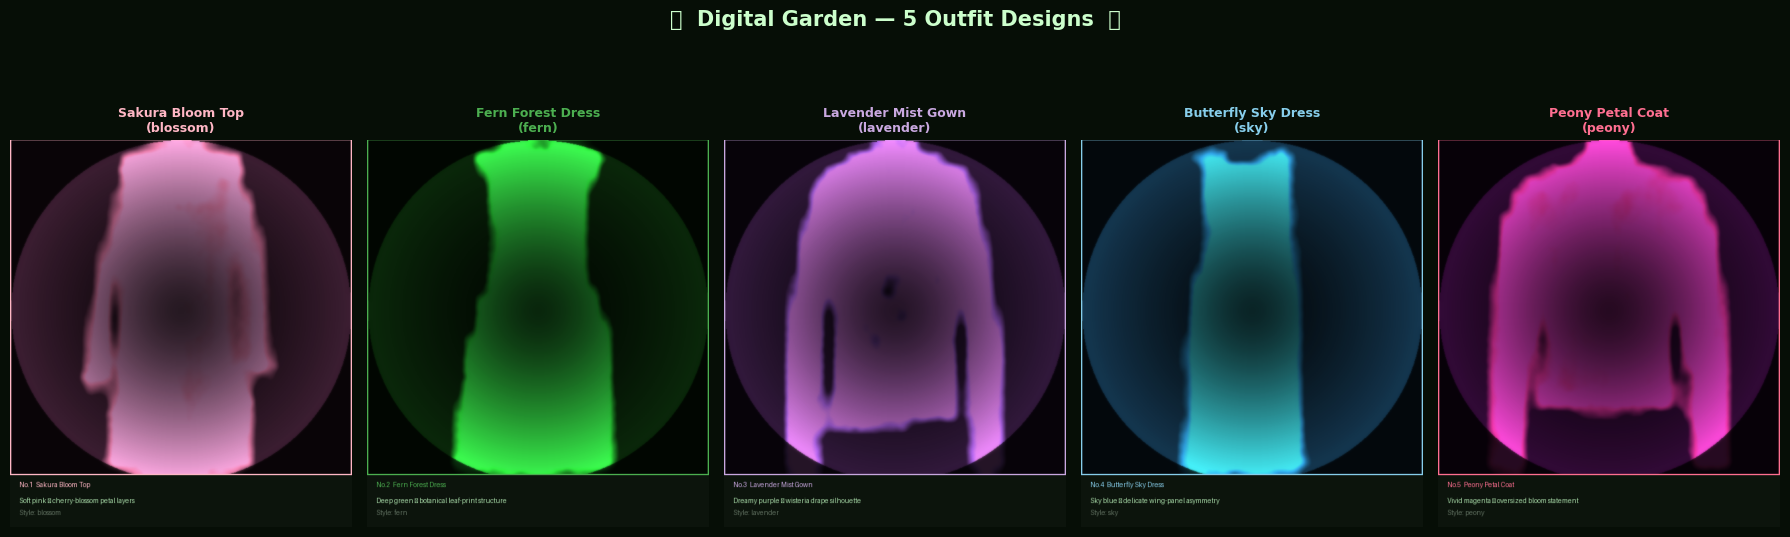

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.patch.set_facecolor("#060e06")
accent_colors = ["#FFB7C5", "#4CAF50", "#C9A8E0", "#87CEEB", "#FF6F91"]
titles = [m[0] for m in outfit_meta]
styles = [m[1] for m in outfit_meta]

for ax, oimg, title, style, accent in zip(axes, outfit_imgs, titles, styles, accent_colors):
    ax.imshow(np.array(oimg))
    ax.set_title(f"{title}\n({style})", color=accent, fontsize=9, pad=6, fontweight="bold")
    ax.axis("off")
    for sp in ax.spines.values():
        sp.set_edgecolor(accent); sp.set_linewidth(2); sp.set_visible(True)

fig.suptitle("🌸  Digital Garden — 5 Outfit Designs  🌿", 
             color="#CCFFCC", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/outfit_gallery.png", dpi=150, bbox_inches="tight",
            facecolor="#060e06")
plt.show()


## 11 · Latent Space Interpolation

🦋 Interpolating between Sakura Bloom → Peony Petal …


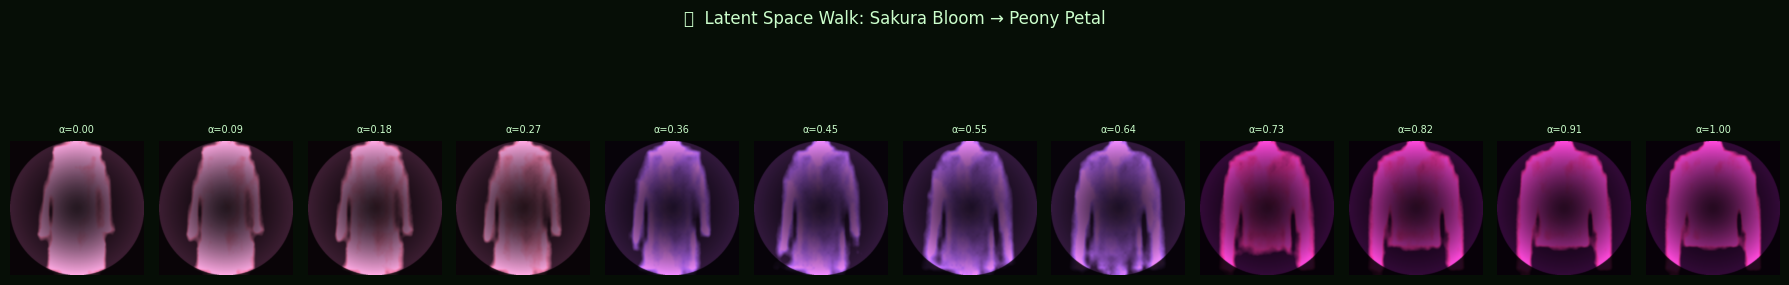

✅ Latent interpolation saved


In [15]:
print("🦋 Interpolating between Sakura Bloom → Peony Petal …")

N_STEPS = 12
interp_imgs = []
interp_styles = []
alpha_vals    = np.linspace(0, 1, N_STEPS)

with torch.no_grad():
    for alpha in alpha_vals:
        z = (1 - alpha) * outfit_z[0:1] + alpha * outfit_z[4:5]
        # Blend styles: blossom → peony
        style = "blossom" if alpha < 0.33 else ("lavender" if alpha < 0.67 else "peony")
        interp_imgs.append(garden_tint(G(z)[0], style))
        interp_styles.append(style)

# Show as strip
fig, axes = plt.subplots(1, N_STEPS, figsize=(18, 3.5))
fig.patch.set_facecolor("#060e06")
for j, (ax, im, alpha) in enumerate(zip(axes, interp_imgs, alpha_vals)):
    ax.imshow(np.array(im))
    ax.set_title(f"α={alpha:.2f}", color="#CCFFCC", fontsize=7)
    ax.axis("off")

fig.suptitle("🌿  Latent Space Walk: Sakura Bloom → Peony Petal",
             color="#CCFFCC", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/latent_interpolation.png", dpi=150,
            bbox_inches="tight", facecolor="#060e06")
plt.show()
print("✅ Latent interpolation saved")


## 12 · Digital Garden Mood Board

🎨 Composing Digital Garden Mood Board …
✅ Mood board saved!


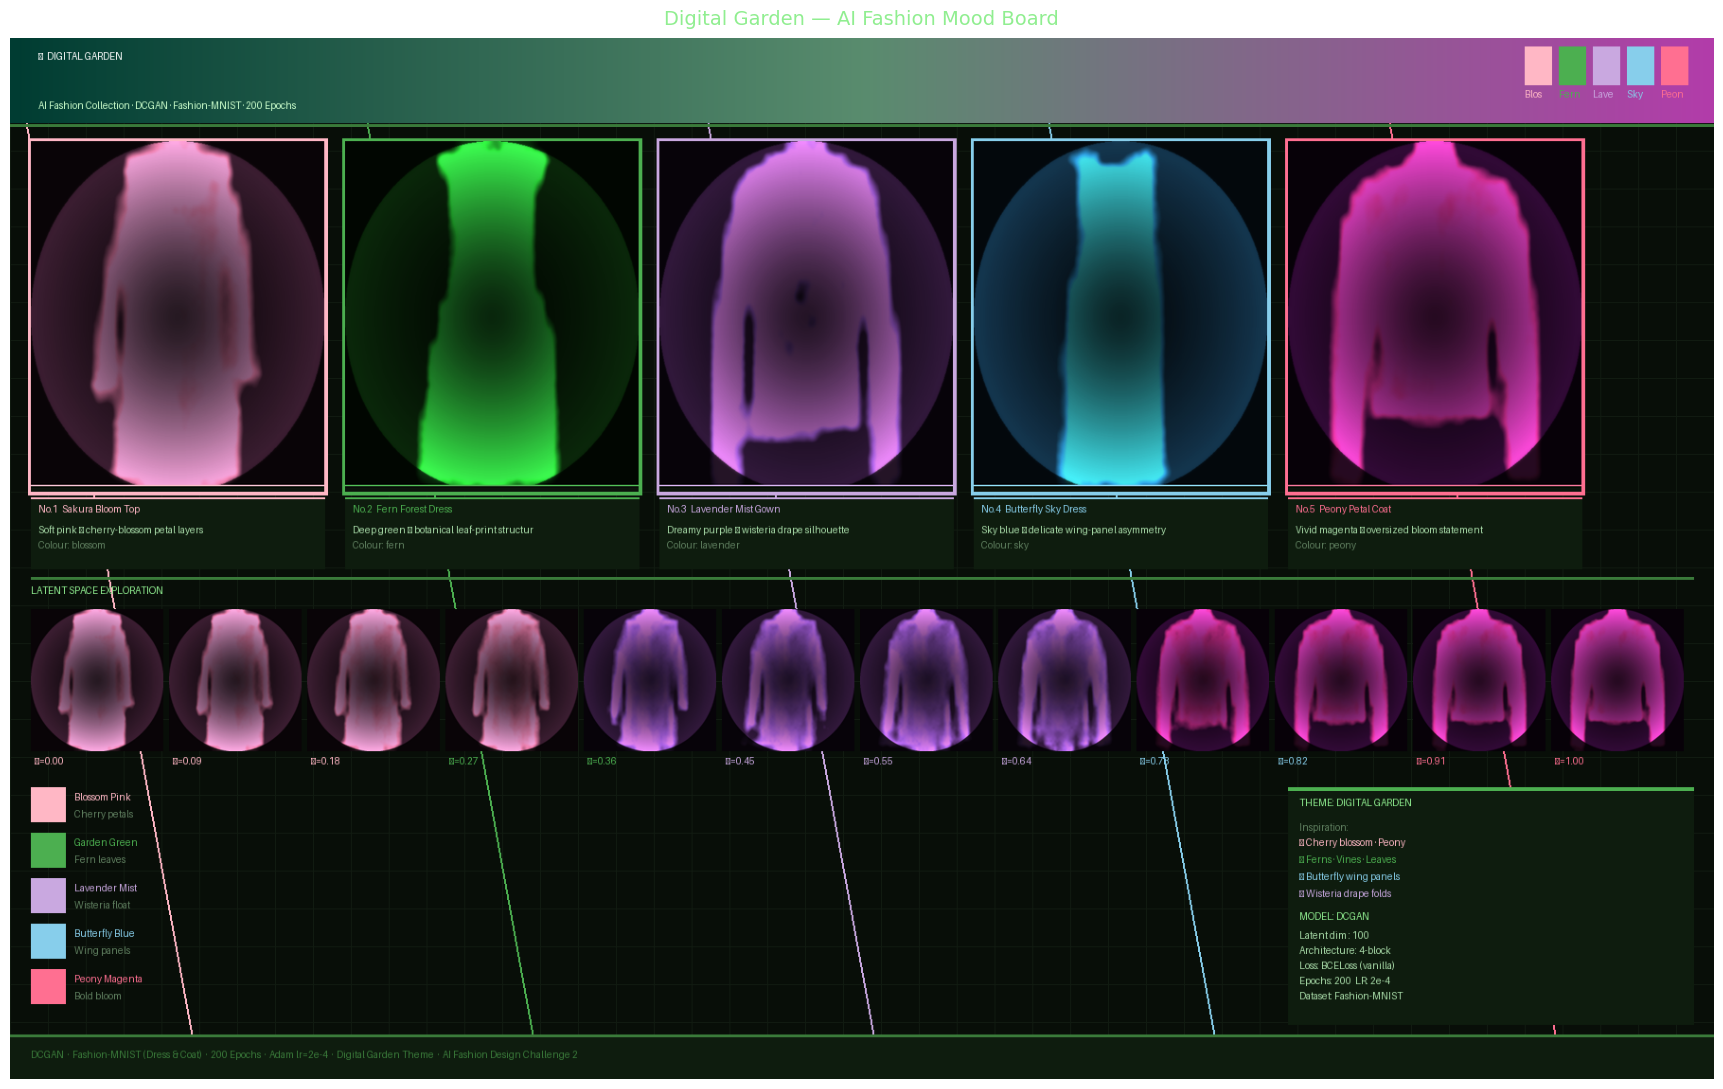

In [16]:
print("🎨 Composing Digital Garden Mood Board …")

# ── Layout constants ──────────────────────────────────────────────────────
MB_W, MB_H = 1800, 1100
PAD        = 22
THUMB_W    = 310
THUMB_H    = 370

mb   = Image.new("RGB", (MB_W, MB_H), (8, 14, 8))
draw = ImageDraw.Draw(mb)

# ── Background texture (subtle grid) ─────────────────────────────────────
for gy in range(0, MB_H, 40):
    draw.line([(0, gy), (MB_W, gy)], fill=(18, 28, 18), width=1)
for gx in range(0, MB_W, 40):
    draw.line([(gx, 0), (gx, MB_H)], fill=(18, 28, 18), width=1)

# ── Decorative diagonal accent lines ─────────────────────────────────────
accent_colors_mb = ["#FFB7C5", "#4CAF50", "#C9A8E0", "#87CEEB", "#FF6F91"]
for i, ac in enumerate(accent_colors_mb):
    ox = i * 360
    draw.line([(ox, 0), (ox + 200, MB_H)], fill=ac + "30", width=2)  # transparent-ish

# ── Fonts ─────────────────────────────────────────────────────────────────
def try_font(path, size, fallback_size=None):
    try: return ImageFont.truetype(path, size)
    except: return ImageFont.load_default()

BOLD_PATH = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
REG_PATH  = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
f_hero   = try_font(BOLD_PATH, 46)
f_sub    = try_font(REG_PATH,  18)
f_label  = try_font(BOLD_PATH, 15)
f_micro  = try_font(REG_PATH,  12)

# ── HEADER ────────────────────────────────────────────────────────────────
# Gradient bar
for x in range(MB_W):
    t = x / MB_W
    r = int(255 * t * 0.7)
    g = int(60 + 80 * (1 - abs(t - 0.5) * 2))
    b = int(50 + 120 * t)
    draw.line([(x, 0), (x, 90)], fill=(r, g, b))

draw.text((PAD + 8, 14), "✦  DIGITAL GARDEN", fill="#FFFFFF", font=f_hero)
draw.text((PAD + 8, 66), "AI Fashion Collection · DCGAN · Fashion-MNIST · 200 Epochs",
          fill="#CCFFCC", font=f_sub)

# Right-side palette swatches
swatch_x = MB_W - 200
for si, (ac, lbl) in enumerate(zip(
        ["#FFB7C5", "#4CAF50", "#C9A8E0", "#87CEEB", "#FF6F91"],
        ["Blossom","Fern","Lavender","Sky","Peony"])):
    sx = swatch_x + si * 36
    draw.rectangle([(sx, 10), (sx + 28, 50)], fill=ac)
    draw.text((sx, 54), lbl[:4], fill=ac, font=f_micro)

draw.rectangle([(0, 92), (MB_W, 94)], fill="#3A7A3A")

# ── MAIN 5-OUTFIT STRIP (row 1) ───────────────────────────────────────────
ROW1_Y = 110
for i, (oimg, (name, style, desc, accent)) in enumerate(zip(outfit_imgs, outfit_meta)):
    x = PAD + i * (THUMB_W + PAD)

    # Accent border
    draw.rectangle([(x - 3, ROW1_Y - 3),
                    (x + THUMB_W + 3, ROW1_Y + THUMB_H + 3)], fill=accent)

    # Thumbnail
    thumb = oimg.crop((2, 2, 514, 514)).resize((THUMB_W, THUMB_H), Image.LANCZOS)
    mb.paste(thumb, (x, ROW1_Y))

    # Label card beneath
    card_h = 75
    label_y = ROW1_Y + THUMB_H + 6
    draw.rectangle([(x, label_y), (x + THUMB_W, label_y + card_h)],
                   fill=(14, 28, 14))
    draw.line([(x, label_y), (x + THUMB_W, label_y)], fill=accent, width=2)
    draw.text((x + 8, label_y + 6),  f"No.{i+1}  {name}", fill=accent,    font=f_label)
    draw.text((x + 8, label_y + 28), desc[:42],             fill="#AADDAA", font=f_micro)
    draw.text((x + 8, label_y + 44), f"Colour: {style}",   fill="#608060", font=f_micro)

# ── SECTION DIVIDER ───────────────────────────────────────────────────────
DIVIDER_Y = ROW1_Y + THUMB_H + 90
draw.rectangle([(PAD, DIVIDER_Y), (MB_W - PAD, DIVIDER_Y + 2)], fill="#3A7A3A")
draw.text((PAD, DIVIDER_Y + 8), "LATENT SPACE EXPLORATION", fill="#90EE90", font=f_label)

# ── INTERPOLATION STRIP (row 2) ───────────────────────────────────────────
INTERP_Y = DIVIDER_Y + 34
INTERP_H  = 150
INTERP_W  = (MB_W - 2 * PAD - (N_STEPS - 1) * 6) // N_STEPS
for j, (im, alpha) in enumerate(zip(interp_imgs, alpha_vals)):
    ix = PAD + j * (INTERP_W + 6)
    ith = im.resize((INTERP_W, INTERP_H), Image.LANCZOS)
    mb.paste(ith, (ix, INTERP_Y))
    ac = accent_colors_mb[min(j * len(accent_colors_mb) // N_STEPS, 4)]
    draw.text((ix + 4, INTERP_Y + INTERP_H + 4), f"α={alpha:.2f}", fill=ac, font=f_micro)

# ── INFO COLUMN (right side, below interp) ───────────────────────────────
INFO_Y = INTERP_Y + INTERP_H + 38
# Theme box
box_x = MB_W - 450
draw.rectangle([(box_x, INFO_Y), (MB_W - PAD, INFO_Y + 250)], fill=(14, 28, 14))
draw.rectangle([(box_x, INFO_Y), (MB_W - PAD, INFO_Y + 3)], fill="#4CAF50")
draw.text((box_x + 12, INFO_Y + 10),  "THEME: DIGITAL GARDEN",  fill="#90EE90",  font=f_label)
draw.text((box_x + 12, INFO_Y + 36),  "Inspiration:",            fill="#608060",  font=f_micro)
draw.text((box_x + 12, INFO_Y + 52),  "🌸 Cherry blossom · Peony",fill="#FFB7C5", font=f_micro)
draw.text((box_x + 12, INFO_Y + 70),  "🌿 Ferns · Vines · Leaves",fill="#4CAF50", font=f_micro)
draw.text((box_x + 12, INFO_Y + 88),  "🦋 Butterfly wing panels", fill="#87CEEB", font=f_micro)
draw.text((box_x + 12, INFO_Y + 106), "💜 Wisteria drape folds",  fill="#C9A8E0", font=f_micro)
draw.text((box_x + 12, INFO_Y + 130), "MODEL: DCGAN",             fill="#90EE90",  font=f_label)
draw.text((box_x + 12, INFO_Y + 150), "Latent dim : 100",         fill="#AADDAA", font=f_micro)
draw.text((box_x + 12, INFO_Y + 166), "Architecture: 4-block",    fill="#AADDAA", font=f_micro)
draw.text((box_x + 12, INFO_Y + 182), "Loss: BCELoss (vanilla)",  fill="#AADDAA", font=f_micro)
draw.text((box_x + 12, INFO_Y + 198), "Epochs: 200  LR: 2e-4",   fill="#AADDAA", font=f_micro)
draw.text((box_x + 12, INFO_Y + 214), "Dataset: Fashion-MNIST",   fill="#AADDAA", font=f_micro)

# ── Colour palette legend ─────────────────────────────────────────────────
PAL_Y = INFO_Y
for si, (ac, lbl, desc2) in enumerate(zip(
    ["#FFB7C5", "#4CAF50", "#C9A8E0", "#87CEEB", "#FF6F91"],
    ["Blossom Pink", "Garden Green", "Lavender Mist", "Butterfly Blue", "Peony Magenta"],
    ["Cherry petals", "Fern leaves", "Wisteria float", "Wing panels", "Bold bloom"]
)):
    py = PAL_Y + si * 48
    draw.rectangle([(PAD, py), (PAD + 36, py + 36)], fill=ac)
    draw.text((PAD + 46, py + 4),  lbl,   fill=ac,       font=f_label)
    draw.text((PAD + 46, py + 22), desc2, fill="#608060", font=f_micro)

# ── FOOTER ────────────────────────────────────────────────────────────────
draw.rectangle([(0, MB_H - 45), (MB_W, MB_H)], fill=(14, 28, 14))
draw.rectangle([(0, MB_H - 47), (MB_W, MB_H - 45)], fill="#3A7A3A")
draw.text((PAD, MB_H - 32),
          "DCGAN  ·  Fashion-MNIST (Dress & Coat)  ·  200 Epochs  ·  Adam lr=2e-4  ·  Digital Garden Theme  ·  AI Fashion Design Challenge 2",
          fill="#3A7A3A", font=f_micro)

mb.save(f"{OUTDIR}/moodboard_digital_garden.png", dpi=(150, 150))
print("✅ Mood board saved!")

# Display inline
plt.figure(figsize=(18, 11))
plt.imshow(np.array(mb))
plt.axis("off")
plt.title("Digital Garden — AI Fashion Mood Board", color="#90EE90",
          fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/moodboard_display.png", dpi=120,
            bbox_inches="tight", facecolor="#060e06")
plt.show()


## 13 · Save & Display Individual Outfit Images

📁 Individual outfit files:
   outfit_1_blossom.png  |  Sakura Bloom Top
   outfit_2_fern.png  |  Fern Forest Dress
   outfit_3_lavender.png  |  Lavender Mist Gown
   outfit_4_sky.png  |  Butterfly Sky Dress
   outfit_5_peony.png  |  Peony Petal Coat


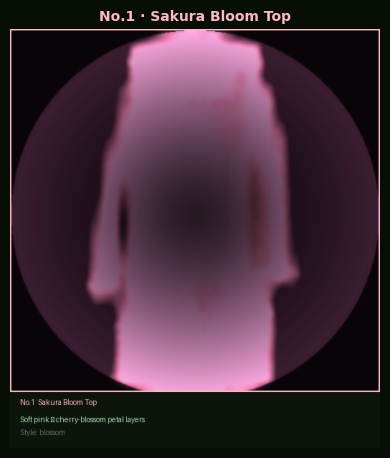

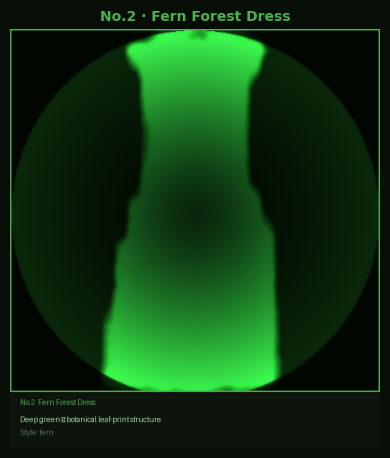

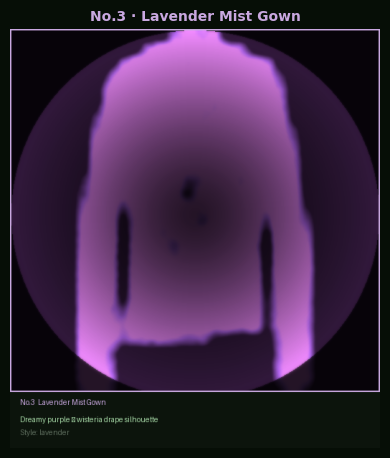

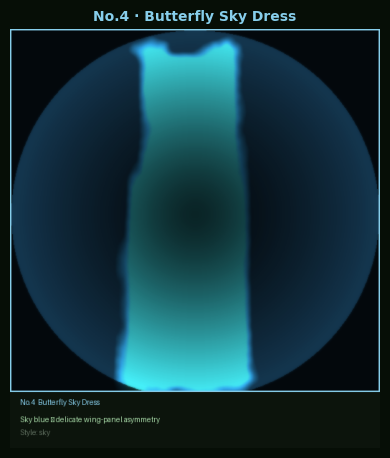

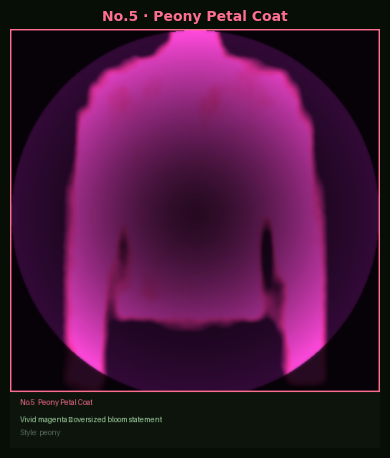

In [17]:
print("📁 Individual outfit files:")
for i, (name, style, desc, accent) in enumerate(outfit_meta):
    path = f"{OUTDIR}/outfit_{i+1}_{style}.png"
    print(f"   outfit_{i+1}_{style}.png  |  {name}")

# Display each individually at larger size
for i, (oimg, (name, style, desc, accent)) in enumerate(zip(outfit_imgs, outfit_meta)):
    fig, ax = plt.subplots(1, 1, figsize=(4, 5))
    fig.patch.set_facecolor("#060e06")
    ax.imshow(np.array(oimg))
    ax.set_title(f"No.{i+1} · {name}", color=accent, fontsize=10, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## 15 · Output Summary

In [18]:
print("🌿 ─── Digital Garden Outputs ───────────────────────────────")
files = {
    "outfit_1_blossom.png"          : "No.1 · Sakura Bloom Dress (pink)",
    "outfit_2_fern.png"             : "No.2 · Fern Forest Coat (green)",
    "outfit_3_lavender.png"         : "No.3 · Lavender Mist Gown",
    "outfit_4_sky.png"              : "No.4 · Butterfly Sky Dress",
    "outfit_5_peony.png"            : "No.5 · Peony Petal Coat (magenta)",
    "moodboard_digital_garden.png"  : "Full mood board (1800×1100)",
    "latent_interpolation.png"      : "12-step latent walk",
    "training_loss.png"             : "G / D loss curves",
    "outfit_gallery.png"            : "5-outfit gallery grid",
    "generator.pth"                 : "Trained Generator weights",
}
for fname, desc in files.items():
    path = f"{OUTDIR}/{fname}"
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists}  {fname:<42} {desc}")
print()
print(f"📂 All files in: {os.path.abspath(OUTDIR)}/")


🌿 ─── Digital Garden Outputs ───────────────────────────────
  ✓  outfit_1_blossom.png                       No.1 · Sakura Bloom Dress (pink)
  ✓  outfit_2_fern.png                          No.2 · Fern Forest Coat (green)
  ✓  outfit_3_lavender.png                      No.3 · Lavender Mist Gown
  ✓  outfit_4_sky.png                           No.4 · Butterfly Sky Dress
  ✓  outfit_5_peony.png                         No.5 · Peony Petal Coat (magenta)
  ✓  moodboard_digital_garden.png               Full mood board (1800×1100)
  ✓  latent_interpolation.png                   12-step latent walk
  ✓  training_loss.png                          G / D loss curves
  ✓  outfit_gallery.png                         5-outfit gallery grid
  ✓  generator.pth                              Trained Generator weights

📂 All files in: c:\Users\18Shr\Desktop\AI FASHION DESIGNER\digital_garden_outputs/
